## **CSDID for first agreement**

Using conflict panel, and filtering for the first agreement active, we will estimate the causal effect of the first agreement on violence.

We will create a sample where control are comparable on violence levels to the treated conflicts.

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines




In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import seaborn as sns
from matplotlib.ticker import FuncFormatter

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# Define golden ratio for height1
golden_ratio = (5**0.5 - 1) / 2  # ≈ 0.618
FIG_WIDTH_IN = 170 / 25.4  # matches typical \linewidth in 12pt LaTeX article
FIG_HEIGHT_IN = FIG_WIDTH_IN * golden_ratio  # aesthetically pleasing height
SUPTITLE_FONTSIZE = 12
plt.rcParams.update(
    {
        # === Font settings ===
        #'text.usetex': True,
        "font.family": "Times New Roman",
        "font.size": 8,  # Base font size
        "axes.labelsize": 8,  # Axis label font
        "axes.titlesize": 12,  # Title font size
        "xtick.labelsize": 8,  # X tick labels
        "ytick.labelsize": 8,  # Y tick labels
        "legend.fontsize": 8,  # Legend text size
        # === Figure settings ===
        "figure.figsize": (FIG_WIDTH_IN, FIG_HEIGHT_IN),  # Size in inches
        "figure.dpi": 300,  # High-res for export
        # === Line/Marker settings ===
        "lines.linewidth": 1.5,
        "lines.markersize": 4,
        # === Grid and style ===
        "axes.grid": True,
        "grid.alpha": 0.4,
        "grid.linestyle": "--",
        # === Legend settings ===
        'legend.frameon': False,        # No frame (border)
        'legend.facecolor': 'none',     # Transparent background
        "legend.edgecolor": "none",  # No edge line (just in case)
        # === Save options ===
        "savefig.format": "svg",
        "savefig.bbox": "tight",  # Avoid extra whitespace
        "savefig.dpi": 300,  # High-res for export
    }
)

In [81]:
df_conflict = pd.read_csv('../../../../data/output/conflict_level/conflict_panel.csv', low_memory=False)
df_conflict["year_mo"] = pd.to_datetime(df_conflict["year_mo"])

df_conflict = df_conflict.sort_values(["conflict_id", "year_mo"])

# Rolling suma de los últimos 6 meses EXCLUYENDO el actual
df_conflict["pre6_best_sum"] = (
    df_conflict.groupby("conflict_id")["best"]
    .transform(lambda x: x.shift(1).rolling(window=6, min_periods=1).sum())
)

# Redefine treatment
df_conflict["agreement_active"] = np.where(
    (df_conflict["agreement"] == 1) & (df_conflict["pre6_best_sum"] > 12),
    1,
    0
)

df_conflict = df_conflict.sort_values(["conflict_id", "year_mo"])

df_conflict["first_agreement"] = (
    (df_conflict["agreement"] == 1) &
    (df_conflict.groupby("conflict_id")["agreement"].cumsum() == 1)
).astype(int)

df_conflict["first_agreement_active"] = (
    (df_conflict["agreement_active"] == 1) &
    (df_conflict.groupby("conflict_id")["agreement_active"].cumsum() == 1)
).astype(int)


In [82]:
# Extraer mes, trimestre
df_conflict['month_num'] = df_conflict['year_mo'].dt.month
df_conflict['quarter'] = np.ceil(df_conflict['month_num'] / 3).astype(int)
 
# Crear variable de trimestre (formato: "YYYY-Q#")
df_conflict['yq'] = (df_conflict['year'].astype(str) + '-Q' + 
                     df_conflict['quarter'].astype(str))
 
# Identificar trimestre del primer acuerdo (con actividad)
df_conflict['first_agree_yq'] = df_conflict['yq'].where(
    df_conflict['first_agreement_active'] == 1
)

df_conflict['first_agreement_quarter'] = (
    df_conflict.groupby('conflict_id')['first_agree_yq']
    .transform('first')
)

df_conflict['first_agreement_date'] = df_conflict['year_mo'].where(
    df_conflict['first_agreement_active'] == 1
)
df_conflict['first_agreement_date'] = (
    df_conflict.groupby('conflict_id')['first_agreement_date']
    .transform('first')
)

In [83]:
treated_id = 332

moz_treat_month = df_conflict.loc[df_conflict["conflict_id"] == treated_id, "first_agreement_date"].min()

print("Mozambique treatment month:", moz_treat_month)

Mozambique treatment month: 1990-07-01 00:00:00


In [84]:
df_conflict["event_time_moz"] = (
    (df_conflict["year_mo"].dt.year - moz_treat_month.year) * 12
    + (df_conflict["year_mo"].dt.month - moz_treat_month.month)
)

In [85]:
df_conflict["is_treated"] = (df_conflict["conflict_id"] == treated_id).astype(int)

df_conflict["is_control"] = (
    (df_conflict["conflict_id"] != treated_id) &
    (
        df_conflict["first_agreement_date"].isna() |
        (df_conflict["first_agreement_date"] > df_conflict["year_mo"])
    )
).astype(int)

In [86]:
df_win = df_conflict.loc[
    (df_conflict["event_time_moz"] >= -18) &
    (df_conflict["event_time_moz"] <= 18)
].copy()

df_win = df_win.loc[
    (df_win["is_treated"] == 1) |
    (df_win["is_control"] == 1)
].copy()

df_win.shape

(7273, 312)

In [87]:
df_win["sample_filtered"] = 1

mask_bad_control = (
    (df_win["is_control"] == 1) &
    (
        (df_win["pre6_best_sum"] < 12) |
        (df_win["pre6_best_sum"].isna())
    )
)

df_win.loc[mask_bad_control, "sample_filtered"] = 0

In [88]:
mean_ctrl_unf = (
    df_win.loc[df_win["is_control"] == 1]
    .groupby("event_time_moz")["log_best"]
    .mean()
    .rename("mean_ctrl_unf")
)

mean_ctrl_filt = (
    df_win.loc[(df_win["is_control"] == 1) & (df_win["sample_filtered"] == 1)]
    .groupby("event_time_moz")["log_best"]
    .mean()
    .rename("mean_ctrl_filt")
)

treated_series = (
    df_win.loc[df_win["is_treated"] == 1, ["event_time_moz", "log_best"]]
    .sort_values("event_time_moz")
    .copy()
)

In [89]:
n_ctrl_unf = (
    df_win.loc[df_win["is_control"] == 1]
    .groupby("event_time_moz")
    .size()
    .rename("n_ctrl_unf")
)

n_ctrl_filt = (
    df_win.loc[(df_win["is_control"] == 1) & (df_win["sample_filtered"] == 1)]
    .groupby("event_time_moz")
    .size()
    .rename("n_ctrl_filt")
)

counts = pd.concat([n_ctrl_unf, n_ctrl_filt], axis=1)
counts.head()

,n_ctrl_unf,n_ctrl_filt
event_time_moz,,
-18,200,NaN
-17,200,14.0
-16,200,19.0
-15,200,23.0
-14,200,28.0


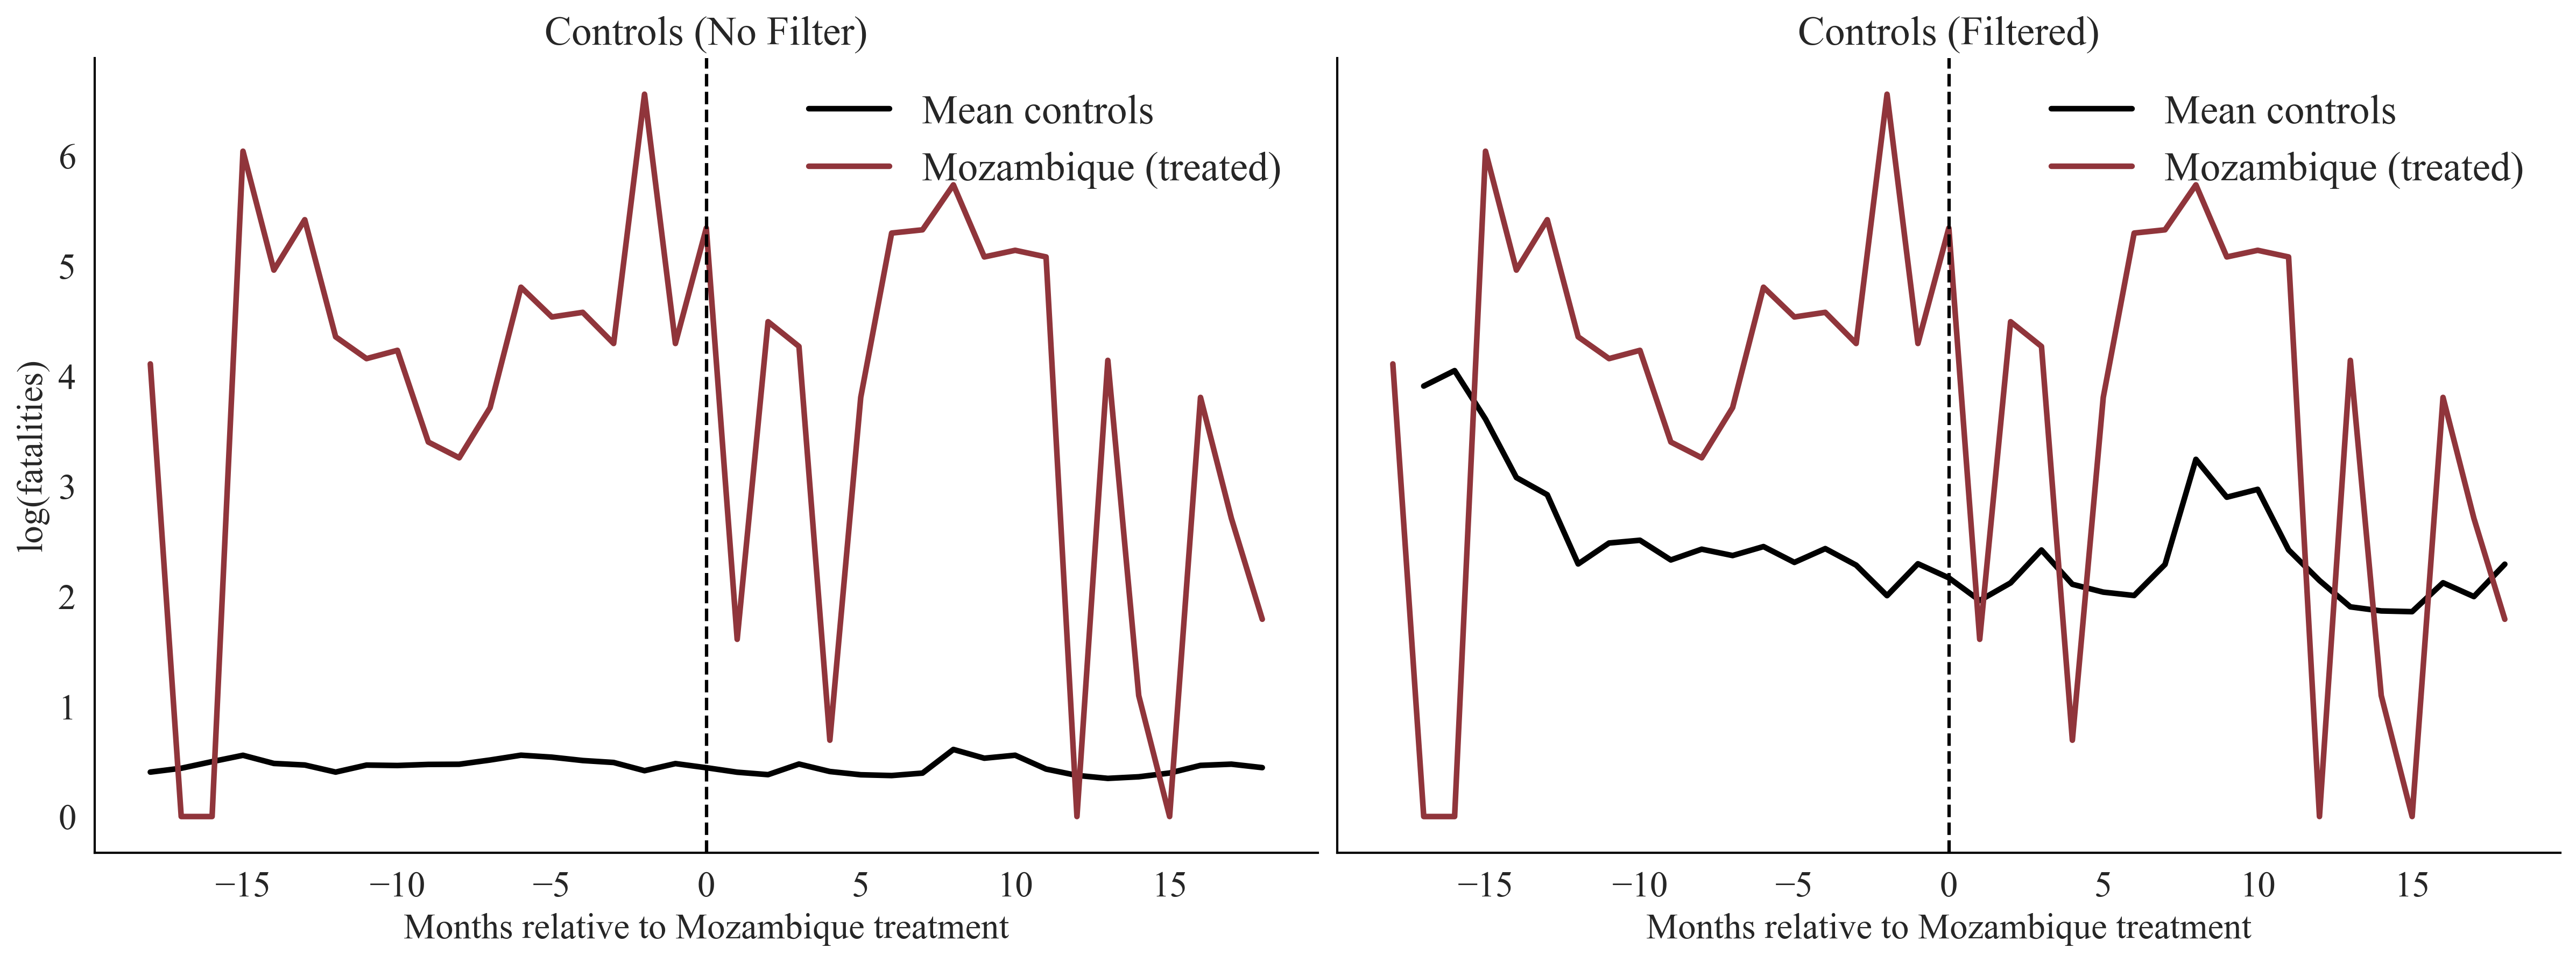

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# -------------------
# Plot 1: no filter
# -------------------
ax = axes[0]

ax.plot(
    mean_ctrl_unf.index,
    mean_ctrl_unf.values,
    linewidth=2.5,
    label="Mean controls",
    color='black'
)

ax.plot(
    treated_series["event_time_moz"],
    treated_series["log_best"],
    linewidth=2.5,
    label="Mozambique (treated)",
    color='#90353B'
)

ax.axvline(0, linestyle="--", color="black")
ax.set_title("Controls (No Filter)", fontsize=18)
ax.set_xlabel("Months relative to Mozambique treatment", fontsize=16)
ax.set_ylabel("log(fatalities)", fontsize=16)
ax.legend(frameon=False, fontsize=18)
ax.tick_params(axis="x", labelsize=16)
ax.tick_params(axis="y", labelsize=16)
# clean borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# spines in black
ax.spines["left"].set_color("black")
ax.spines["bottom"].set_color("black")
# no grid lines
ax.grid(False)


# -------------------
# Plot 2: with filter
# -------------------
ax = axes[1]

ax.plot(
    mean_ctrl_filt.index,
    mean_ctrl_filt.values,
    linewidth=2.5,
    label="Mean controls",
    color='black'
)

ax.plot(
    treated_series["event_time_moz"],
    treated_series["log_best"],
    linewidth=2.5,
    label="Mozambique (treated)",
    color='#90353B'
)

ax.axvline(0, linestyle="--", color="black")
ax.set_title("Controls (Filtered)", fontsize=18)
ax.set_xlabel("Months relative to Mozambique treatment", fontsize=16)
ax.legend(frameon=False, fontsize=18)
ax.tick_params(axis="x", labelsize=16)
ax.tick_params(axis="y", labelsize=16)
# clean borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# spines in black
ax.spines["left"].set_color("black")
ax.spines["bottom"].set_color("black")
# no grid lines
ax.grid(False)

plt.tight_layout()
plt.show()

## Plot

In [ ]:
for l in range(1, 7):
    df_conflict[f"lag{l}_best"] = df_conflict.groupby("conflict_id")["best"].shift(l)

lag_cols = [f"lag{l}_best" for l in range(1, 7)]
df_conflict["deaths_prev6m"] = df_conflict[lag_cols].sum(axis=1, min_count=1)

df_conflict.drop(columns=lag_cols, inplace=True)

activity_threshold = 12

In [ ]:
df_conflict['D_first_agreement_active'] = (df_conflict.groupby('conflict_id')['first_agreement_active'].cumsum() > 0).astype(int)
df_conflict = df_conflict.sort_values(['conflict_id', 'year_mo'])
#df_conflict = df_conflict[['conflict_id', 'year_mo', 'year_mo_numeric', 'isocode', 'agreement', 'agreement_active', 'first_agreement_active', 'D_first_agreement_active', 'best','log_best']]
#df_conflict.to_csv('../../data/output/conflict_level/conflict_data_filtered.csv')


### **Construct semester panel**

---

In [ ]:
# Extraer año y mes
df_conflict['year'] = df_conflict['year_mo'].dt.year
df_conflict['month'] = df_conflict['year_mo'].dt.month

# Crear semestre (1 o 2)
df_conflict['semester'] = np.where(df_conflict['month'] <= 6, 1, 2)

# Crear variable year_semester (formato YYYYS)
df_conflict['year_semester'] = df_conflict['year'] * 10 + df_conflict['semester']

# Agregar a nivel semestral
df_semester = df_conflict.groupby(['conflict_id', 'year_semester']).agg({
    'best': 'sum',  # sum de best por semestre
    'D_first_agreement_active': 'max'  # Máximo (si hubo tratamiento en algún mes)
}).reset_index()

df_semester['log_best'] = np.log(df_semester['best'] + 1)  # log de best para el panel semestral

# Ordenar
df_semester = df_semester.sort_values(['conflict_id', 'year_semester'])

# Guardar el panel semestral
df_semester.to_csv('../../data/output/conflict_level/conflict_data_filtered_semester.csv')